## ECE 403 Final Project
#### By: Alex Rios & Graham Philips
#### Topic: Implement a Generative AI Model

---
## Environment Setup

```bash
conda create -n ece403 python=3.13 -y
conda activate ece403
conda install pytorch torchvision -c pytorch
conda install matplotlib pandas scikit-learn
pip install ipykernel kagglehub
```


In [1]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import kagglehub
import pandas as pd
import os
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from PIL import Image

# Create seed to have consistent results
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
# Check for cuda
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

seed_everything(42)
print(f"Using device: {device}")

c:\Users\alexr\miniforge3\envs\ece403\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


---
## Section 1: Dataset Setup

We can automatically download our dataset through this code and have it appear in c:\Users\alexr\.cache\kagglehub\datasets\yehongjiang\pokemon-sprites-images\versions\1\pokemon_images. However, it would be different for each computer running this project. For the sake of this project, I downloaded it into my personal computer and moved it directly into this directory.

**Please use the provided dataset folder called "pokemon_images" instead of using provided code to keep dataset consistent**

In [2]:
# Download latest version
path = kagglehub.dataset_download("yehongjiang/pokemon-sprites-images")

print("Path to dataset files:", path)

100%|██████████| 19.7M/19.7M [00:00<00:00, 26.5MB/s]

Extracting files...


Path to dataset files: C:\Users\alexr\.cache\kagglehub\datasets\yehongjiang\pokemon-sprites-images\versions\1


### 1.1 Pokemon Dataset

Instead of using standard dataset loaders we can create our own to fit our GAN needs. The hardest part of this class is to match each picture to the correct label (pokemon type). If we can show that our image has the correct type, that will help train our model to use these conditional labels to generate a similar pokemon of that type.

In [2]:
class PokemonDataset(Dataset):
    def __init__(self, sprites_dir: str | Path, pokedex_csv: str | Path, transform=None):
        self.transform = transform
        # list of (image_path, type_index)
        self.samples = []  
        # Build pokedex_id to type mapping
        df = pd.read_csv(pokedex_csv)
        id_to_type = dict(zip(df["pokedex_id"], df["type1"]))
        # Build type to index mapping
        self.classes = sorted(df["type1"].unique().tolist())
        type_to_idx  = {t: i for i, t in enumerate(self.classes)}

         # Walk sprites folder
        sprites_dir = Path(sprites_dir)
        for pokemon_folder in sorted(sprites_dir.iterdir()):
            if not pokemon_folder.is_dir():
                continue
            # Extract pokedex_id from folder name: "0000-Bulbasaur-1" = 1
            try:
                pokedex_id = int(pokemon_folder.name.split("-")[-1])
            except ValueError:
                continue
            # Look up type
            if pokedex_id not in id_to_type:
                continue
            type_name = id_to_type[pokedex_id]
            type_idx  = type_to_idx[type_name]

            # Get front/back normal images
            img_path = pokemon_folder / "front" / "normal"
            if not img_path.exists():
                continue
            images = list(img_path.glob("*.png")) + list(img_path.glob("*.jpg"))
            if not images:
                continue
            for img in images:
              self.samples.append((img, type_idx))

        print(f"Loaded {len(self.samples)} images across {len(self.classes)} types")
        print(f"Classes: {self.classes}")
    # Standard len function for class in ML algorithms
    def __len__(self):
        return len(self.samples)
    # Standard get item function for class in ML algorithms
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label       
# Build our pokemon dataset handling tranformations, minor augmenetation, and dataloaders
def build_pokemon_loaders(
    data_root: str | Path = "pokemon_images",
    batch_size: int = 64,
    eval_batch_size: int = 128,
    image_size: int = 96,
    val_split: float = 0.1,
) -> tuple[DataLoader, DataLoader]:
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])
    # Construct dataset
    full_dataset = PokemonDataset(
        sprites_dir = Path(data_root) / "sprites", 
        pokedex_csv  = Path(data_root) / "pokedex.csv",
        transform=transform)
    # Determine training and validation split
    train_idx, val_idx = train_test_split(range(len(full_dataset)), test_size = 0.1, random_state = 42)  

    train_dataset = Subset(full_dataset, train_idx)
    val_dataset = Subset(full_dataset, val_idx)
    # Load training dataset
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )
    # Load validation dataset
    test_loader = DataLoader(
        val_dataset,
        batch_size=eval_batch_size,
        shuffle=False,
        num_workers=0,
    )
    print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
    return train_loader, test_loader

sprites_dir = Path("pokemon_images/sprites")

In [3]:
# Denormalize images when needed
def denormalize(images: torch.Tensor) -> torch.Tensor:
    return images.mul(0.5).add(0.5).clamp(0.0, 1.0)

# Print out images
def show_batch(loader: DataLoader, num_images: int = 8) -> None:
    # Retrieve pokemon types from dataset
    pokemon_types = loader.dataset.dataset.classes
    # Construct batch to show each pokemon seperately
    images, labels = next(iter(loader))
    images = denormalize(images[:num_images])
    fig, axes = plt.subplots(1, num_images, figsize=(1.8 * num_images, 2.5))
    for ax, image, label in zip(axes, images, labels[:num_images]):
        ax.imshow(image.permute(1, 2, 0))
        ax.set_title(pokemon_types[int(label)])
        ax.axis("off")
    fig.suptitle("Pokemon Samples")
    plt.tight_layout()
    plt.show()

Loaded 4086 images across 18 types
Classes: ['Bug', 'Dark', 'Dragon', 'Electric', 'Fairy', 'Fighting', 'Fire', 'Flying', 'Ghost', 'Grass', 'Ground', 'Ice', 'Normal', 'Poison', 'Psychic', 'Rock', 'Steel', 'Water']
Train: 3677 | Val: 409
image batch shape: torch.Size([64, 3, 96, 96])
label batch shape: torch.Size([64])


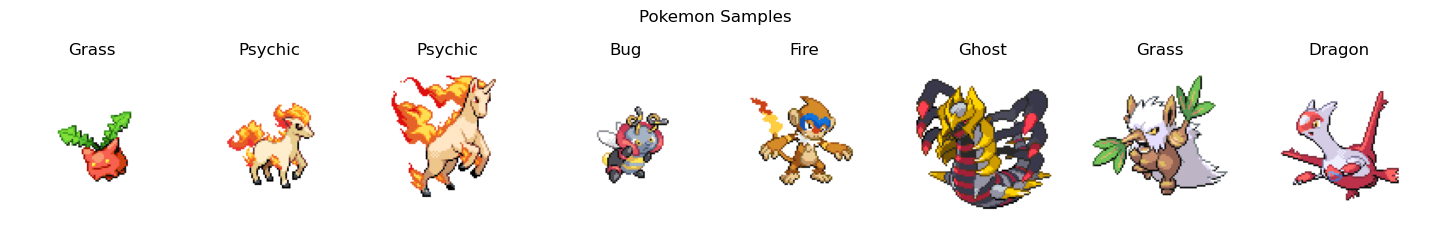

In [4]:
# load sample training and test set
train_loader, test_loader = build_pokemon_loaders(
    data_root="pokemon_images",
    batch_size=64,
    eval_batch_size=128,
    image_size=96,
)

POKEMON_TYPES = train_loader.dataset.dataset.classes
NUM_CLASSES = len(POKEMON_TYPES)

images, labels = next(iter(train_loader))
print(f"image batch shape: {images.shape}")
print(f"label batch shape: {labels.shape}")
assert images.shape[1:] == (3, 96, 96)
assert labels.ndim == 1
show_batch(train_loader)

---
## Section 2: GAN

### 2.1 Weight Initialization

We want to initialize our cgan weights. We follow the standard DCGAN weight implementation where weights are initialized from a normal distribution:
- Mean = `0`
- Standard Deviation = `0.02`.

In [5]:
def initialize_gan_weights(module: nn.Module) -> None:
    # convolution weights: Normal(mean=0.0, std=0.02)
    if isinstance(module, nn.Conv2d) or isinstance(module, nn.ConvTranspose2d):
        nn.init.normal_(module.weight.data, mean= 0.0, std=0.02)
        # supported biases should be initialized to zero
        nn.init.constant_(module.bias.data, 0)
    # batch norm weights: Normal(mean=1.0, std=0.02)
    elif isinstance(module, nn.BatchNorm2d):
        nn.init.normal_(module.weight.data, mean=1.0, std=0.02)
        nn.init.constant_(module.bias.data, 0)

### 2.2 Generator and Discriminator Classes

It's easiest to create classes for both the generator and discriminator network. The architecture of our network is as follows:

Generator:

$z \to 256 \to 512 \to 1024 \to 2048 \to 27648 \to 3 \times 96 \times 96$

Discriminator:

$3 \times 96 \times 96 \to 27648 \to 2048 \to 1024 \to 512 \to 256 \to 1$

In [6]:
class MLPGenerator(nn.Module):
    def __init__(self, latent_dim: int = 100):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048),
            nn.LeakyReLU(0.2),
            nn.Linear(2048, 96 * 96 * 3),
            nn.Tanh()
        )
        self.apply(initialize_gan_weights)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.layers(z).view(-1, 3, 96, 96)

In [7]:
class MLPDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(96 * 96 * 3, 2048),
            nn.LeakyReLU(0.2),
            nn.Linear(2048, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )
        self.apply(initialize_gan_weights)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)

### 2.3 Adversarial Loss

We will use `binary_cross_entropy_with_logits`, which means:

- the discriminator outputs logits
- we compare real logits to target `1`
- we compare fake logits to target `0`
- the generator tries to make fake logits look like real ones


In [8]:
def gan_discriminator_loss(real_logits: torch.Tensor, fake_logits: torch.Tensor) -> torch.Tensor:
    criterion = nn.BCEWithLogitsLoss()
    # compare real logits against ones with label smoothing
    real_loss = criterion(real_logits, torch.ones_like(real_logits) * 0.9)
    # compare fake logits against zeros
    fake_loss = criterion(fake_logits, torch.zeros_like(fake_logits))
    # return the average of the two losses
    return (real_loss + fake_loss) / 2

def gan_generator_loss(fake_logits: torch.Tensor, fake_images) -> torch.Tensor:
    criterion = nn.BCEWithLogitsLoss()
    # compare fake logits against ones
    fake_loss = criterion(fake_logits, torch.ones_like(fake_logits))
    # Total variation loss to reduce speckle noise
    return fake_loss

### 2.4 GAN Training Epoch

Each iteration should:

1. sample a batch of real images
2. update the discriminator using real images and detached fake images
3. sample fresh noise
4. update the generator twice per each discriminator update to enhance training

In [13]:
def train_gan_epoch(
    generator: nn.Module,
    discriminator: nn.Module,
    loader: DataLoader,
    g_optimizer: torch.optim.Optimizer,
    d_optimizer: torch.optim.Optimizer,
    latent_dim: int,
    device: torch.device,
) -> dict[str, object]:
    # Store total losses
    total_gen_loss = 0
    total_disc_loss = 0

    for x, _ in loader:
        # Retrieve images and send to GPU
        x = x.to(device)

        # Discriminator Updates
        d_optimizer.zero_grad()
        real_logits = discriminator(x)
        # Generator fake logits
        fake_images = generator(torch.randn(x.shape[0], latent_dim, device=device))
        fake_logits = discriminator(fake_images.detach())
        # Discriminator loss
        dis_loss = gan_discriminator_loss(real_logits, fake_logits)
        dis_loss.backward()
        d_optimizer.step()
        total_disc_loss += dis_loss.item()
        # Train generator twice per discriminator update to help it learn faster
        for _ in range(2):
        # Generator Updates
            g_optimizer.zero_grad()
            fake_images = generator(torch.randn(x.shape[0], latent_dim, device=device))
            fake_logits = discriminator(fake_images)
            # Generator Loss
            gen_loss = gan_generator_loss(fake_logits, fake_images)
            gen_loss.backward()
            g_optimizer.step()
        total_gen_loss += gen_loss.item()
    return {"generator_loss": total_gen_loss / len(loader), "discriminator_loss": total_disc_loss / len(loader)}

def fit_gan(
    generator: nn.Module,
    discriminator: nn.Module,
    loader: DataLoader,
    latent_dim: int,
    device: torch.device,
    epochs: int = 5,
    g_lr: float = 2e-4,
    d_lr: float = 5e-5,
    betas: tuple[float, float] = (0.5, 0.999),
) -> dict[str, list[float]]:
    generator = generator.to(device)
    discriminator = discriminator.to(device)
    g_optimizer = torch.optim.Adam(generator.parameters(), lr=g_lr, betas=betas)
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=d_lr, betas=betas)
    history = {"generator_loss": [], "discriminator_loss": []}

    for epoch in range(epochs):
        metrics = train_gan_epoch(
            generator=generator,
            discriminator=discriminator,
            loader=loader,
            g_optimizer=g_optimizer,
            d_optimizer=d_optimizer,
            latent_dim=latent_dim,
            device=device,
        )

        history["generator_loss"].append(metrics["generator_loss"])
        history["discriminator_loss"].append(metrics["discriminator_loss"])
        print(
            f"epoch {epoch + 1:03d}/{epochs:03d} | "
            f"G: {metrics['generator_loss']:.4f} | "
            f"D: {metrics['discriminator_loss']:.4f}"
        )
    return history

### 2.5 Plotting Loss & Image Generation

This is a simple plot function that displays our loss from our discriminator and our generator. Alongside our plots we make a `show_gan_samples`to generate sample images from our GAN

In [10]:
def plot_loss_curves(history: dict[str, list[float]], title: str) -> None:
    plt.figure(figsize=(8, 4))
    for key, values in history.items():
        plt.plot(values, label=key)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

@torch.no_grad()
def show_gan_samples(
    generator: nn.Module,
    latent_dim: int,
    device: torch.device,
    num_images: int = 16,
    title: str = "Generated Samples",
) -> None:
    generator.eval()
    noise = torch.randn(num_images, latent_dim, device=device)
    samples = denormalize(generator(noise).cpu())

    ncols = 4
    nrows = (num_images + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
    axes = axes.flatten()
    for ax, image in zip(axes, samples):
        ax.imshow(image.permute(1, 2, 0))
        ax.axis("off")
    for ax in axes[num_images:]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

### 2.6 Train Model

We now want to train our model. We check to make sure the logits and images are the correct shape that match the required output into the discriminator and train with `fit_gan`. We deploy some sample batches to check our output using `show_gan_samples`.

In [15]:
latent_dim = 100
gan_generator = MLPGenerator(latent_dim=latent_dim).to(device)
gan_discriminator = MLPDiscriminator().to(device)

# Generate random noise
noise = torch.randn(4, latent_dim, device=device)

# Determine image and logits size
fake_images = gan_generator(noise)
fake_logits = gan_discriminator(fake_images)

print("mlp fake shape:", fake_images.shape)
print("mlp logits shape:", fake_logits.shape)

# Error handling
assert fake_images.shape == (4, 3, 96, 96)
assert fake_logits.shape == (4, 1)

mlp fake shape: torch.Size([4, 3, 96, 96])
mlp logits shape: torch.Size([4, 1])


epoch 001/100 | G: 0.6772 | D: 0.6833
epoch 002/100 | G: 0.7131 | D: 0.6931
epoch 003/100 | G: 0.7335 | D: 0.6917
epoch 004/100 | G: 0.7336 | D: 0.6921
epoch 005/100 | G: 0.7447 | D: 0.6927
epoch 006/100 | G: 0.7515 | D: 0.6927
epoch 007/100 | G: 0.7501 | D: 0.6933
epoch 008/100 | G: 0.7639 | D: 0.6907
epoch 009/100 | G: 0.7627 | D: 0.6906
epoch 010/100 | G: 0.7555 | D: 0.6900
epoch 011/100 | G: 0.7682 | D: 0.6900
epoch 012/100 | G: 0.7696 | D: 0.6906
epoch 013/100 | G: 0.7734 | D: 0.6901
epoch 014/100 | G: 0.7660 | D: 0.6890
epoch 015/100 | G: 0.7740 | D: 0.6884
epoch 016/100 | G: 0.7795 | D: 0.6889
epoch 017/100 | G: 0.7842 | D: 0.6894
epoch 018/100 | G: 0.7832 | D: 0.6886
epoch 019/100 | G: 0.7903 | D: 0.6890
epoch 020/100 | G: 0.7918 | D: 0.6888
epoch 021/100 | G: 0.7914 | D: 0.6885
epoch 022/100 | G: 0.7905 | D: 0.6888
epoch 023/100 | G: 0.7987 | D: 0.6895
epoch 024/100 | G: 0.7984 | D: 0.6886
epoch 025/100 | G: 0.7952 | D: 0.6886
epoch 026/100 | G: 0.7971 | D: 0.6876
epoch 027/10

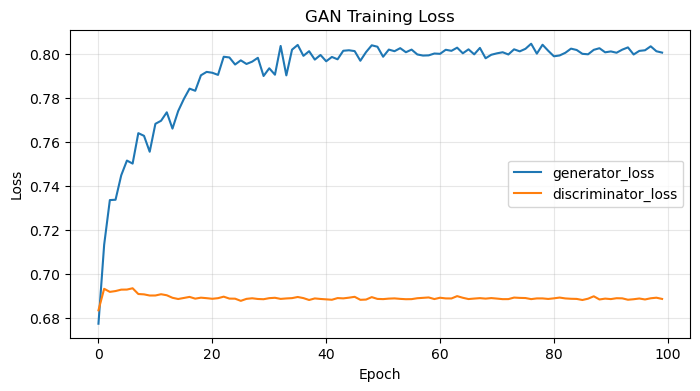

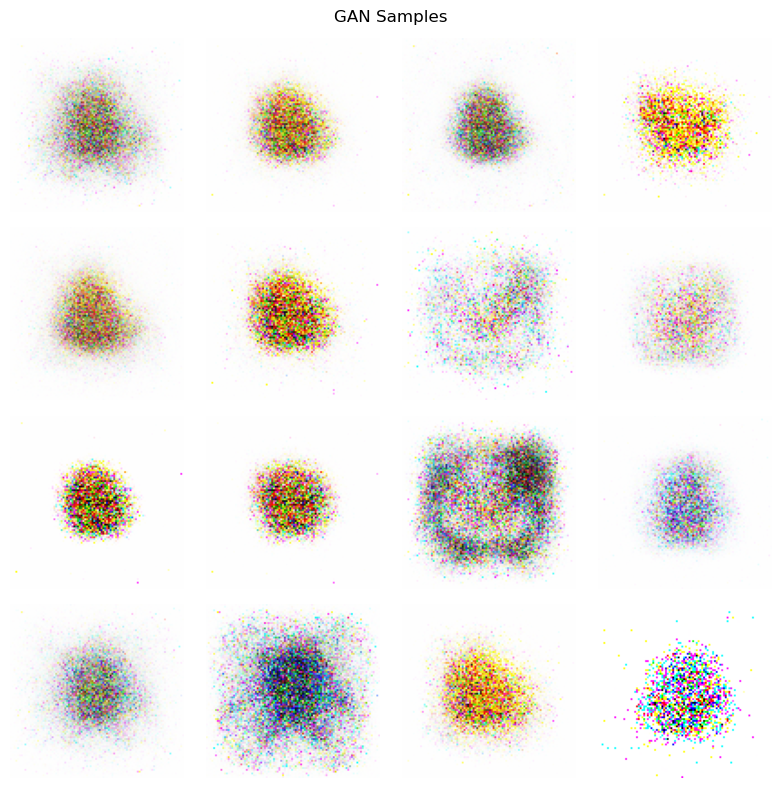

In [16]:
gan_history = fit_gan(
    generator=gan_generator,
    discriminator=gan_discriminator,
    loader=train_loader,
    latent_dim=latent_dim,
    device=device,
    epochs=100,
)

plot_loss_curves(gan_history, title="GAN Training Loss")

show_gan_samples(
    gan_generator.to(device),
    latent_dim=latent_dim,
    device=device,
    title="GAN Samples",
)

---
## Section 3: cGAN Set-up


### 3.1 Generator and Discriminator Class
Both networks consider the number of classes as a parameter to use for conditional labeling. The architecture of our network is as follows:

Generator:

$z \oplus e_{type} \to 512 \times 8 \times 8 \to 256 \times 16 \times 16 \to 128 \times 32 \times 32 \to 64 \times 64 \times 64 \to 32 \times 68 \times 68 \to 3 \times 96 \times 96$

Discriminator:

$4 \times 96 \times 96 \to 64 \times 48 \times 48 \to 128 \times 24 \times 24 \to 256 \times 12 \times 12 \to 512 \times 6 \times 6 \to 512 \times 6 \times 6 \to 1$


In [ ]:
class cGANGenerator(nn.Module):
    def __init__(self, latent_dim: int = 100, num_classes: int = 18, embed_dim: int = 50):
        super().__init__()
        # Type embedding that maps class infex to a learned vector
        self.embedding = nn.Embedding(num_classes, embed_dim)

        # Projecting noise and embedding to spatial feature map
        self.project = nn.Linear(latent_dim + embed_dim, 512 * 6 * 6)
        self.conv_layers = nn.Sequential(
            # 6 x 6 to 12 x 12
          nn.ConvTranspose2d(512, 256, kernel_size=4, stride= 2, padding=1),
          nn.BatchNorm2d(256),
          nn.ReLU(),
          # 12 x 12 to 24 x 24
          nn.ConvTranspose2d(256, 128, kernel_size=4, stride= 2, padding=1),
          nn.BatchNorm2d(128),
          nn.ReLU(),
          # 24 x 24 to 48 x 48
          nn.ConvTranspose2d(128, 64, kernel_size=4, stride= 2, padding=1),
          nn.BatchNorm2d(64),
          nn.ReLU(),
          # 48 x 48 to 96 x 96
          nn.ConvTranspose2d(64, 32, kernel_size=4, stride= 2, padding=1),
          nn.BatchNorm2d(32),
          nn.ReLU(),
          # Final layer
          nn.Conv2d(32, 3, kernel_size=3, stride=1, padding=1),
          nn.Tanh()
        )
        self.apply(initialize_gan_weights)

    def forward(self, z: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        # Concatenate noise and type embedding
        embed = self.embedding(labels)
        # (batch, embed_dim)
        x = torch.cat([z, embed], dim=1)
        # (batch, latent_dim + latent_dim)
        x = self.project(x).view(-1, 512, 6, 6)
        # Return generated images of shape (batch_size, 3, 96, 96).
        return self.conv_layers(x)

In [ ]:
class cGANDiscriminator(nn.Module):
    def __init__(self, num_classes: int = 18, embed_dim: int = 50, image_size: int = 96):
        super().__init__()
        # Type embedding for discriminator
        self.embedding = nn.Embedding(num_classes, embed_dim)
        # Project embedding to a spatial map
        self.embed_proj = nn.Linear(embed_dim, image_size * image_size)
        self.image_size = image_size
        # Sequential discrim layer
        self.layers = nn.Sequential(
            # 96 x 96 to 48 x 48
            nn.Conv2d(4, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            # 48 x 48 to 24 x 24
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            # 24 x 24 to 12 x 12
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            # 12 x 12 to 6 x 6
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            # Final layer
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(512 * 6 * 6, 1)
        )
        self.apply(initialize_gan_weights)

    def forward(self, x: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        # (batch, embed_dim)
        embed = self.embedding(labels) 
        # (batch, 96*96)                                   
        embed = self.embed_proj(embed)  
        # (batch, 1, 96, 96)                                  
        embed = embed.view(-1, 1, self.image_size, self.image_size) 
        # (batch, 4, 96, 96)      
        x = torch.cat([x, embed], dim=1)                                  
        return self.layers(x)

### 3.2 cGAN Training Epoch

To keep our results consistent, we employ the same training loop but consider labels when conditioning

In [ ]:
def train_cgan_epoch(
    generator: nn.Module,
    discriminator: nn.Module,
    loader: DataLoader,
    g_optimizer: torch.optim.Optimizer,
    d_optimizer: torch.optim.Optimizer,
    latent_dim: int,
    device: torch.device,
) -> dict[str, object]:
    # Store total losses
    total_gen_loss = 0
    total_disc_loss = 0

    for x, labels in loader:
        # Retrieve images and send to GPU
        x = x.to(device)
        labels = labels.to(device)

        # Discriminator Updates
        d_optimizer.zero_grad()
        real_logits = discriminator(x, labels)
        # Generator fake logits
        fake_images = generator(torch.randn(x.shape[0], latent_dim, device=device), labels)
        fake_logits = discriminator(fake_images.detach(), labels)
        # Discriminator loss
        dis_loss = gan_discriminator_loss(real_logits, fake_logits)
        dis_loss.backward()
        d_optimizer.step()
        total_disc_loss += dis_loss.item()
        # Train generator twice per discriminator update to help it learn faster
        for _ in range(2):
        # Generator Updates
            g_optimizer.zero_grad()
            fake_images = generator(torch.randn(x.shape[0], latent_dim, device=device), labels)
            fake_logits = discriminator(fake_images, labels)
            # Generator Loss
            gen_loss = gan_generator_loss(fake_logits, fake_images)
            gen_loss.backward()
            g_optimizer.step()
        total_gen_loss += gen_loss.item()
    return {"generator_loss": total_gen_loss / len(loader), "discriminator_loss": total_disc_loss / len(loader)}

def fit_cgan(
    generator: nn.Module,
    discriminator: nn.Module,
    loader: DataLoader,
    latent_dim: int,
    device: torch.device,
    epochs: int = 5,
    g_lr: float = 2e-4,
    d_lr: float = 5e-5,
    betas: tuple[float, float] = (0.5, 0.999),
) -> dict[str, list[float]]:
    # Send generator and discriminator network to GPU
    generator = generator.to(device)
    discriminator = discriminator.to(device)
    g_optimizer = torch.optim.Adam(generator.parameters(), lr=g_lr, betas=betas)
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=d_lr, betas=betas)
    history = {"generator_loss": [], "discriminator_loss": []}

    for epoch in range(epochs):
        metrics = train_cgan_epoch(
            generator=generator,
            discriminator=discriminator,
            loader=loader,
            g_optimizer=g_optimizer,
            d_optimizer=d_optimizer,
            latent_dim=latent_dim,
            device=device,
        )

        history["generator_loss"].append(metrics["generator_loss"])
        history["discriminator_loss"].append(metrics["discriminator_loss"])
        print(
            f"epoch {epoch + 1:03d}/{epochs:03d} | "
            f"G: {metrics['generator_loss']:.4f} | "
            f"D: {metrics['discriminator_loss']:.4f}"
        )
    return history

---
## Section 2: DCGAN

### 2.1 Why Move to a Convolutional GAN?

MNIST images have strong local spatial structure. A DCGAN can exploit that structure by:

- using convolutions in the discriminator
- using learned upsampling in the generator
- preserving spatial layout instead of flattening everything immediately

This usually improves sample quality and training stability compared with a plain MLP GAN.


In [ ]:
latent_dim = 100
cgan_generator = cGANGenerator(latent_dim=latent_dim, num_classes=18).to(device)
cgan_discriminator = cGANDiscriminator(num_classes=18).to(device)
# Generate random noise and label
noise = torch.randn(4, latent_dim, device=device)
labels = torch.randint(0, 18, (4,), device= device)
# Determine image and logits size
fake_images = cgan_generator(noise, labels)
fake_logits = cgan_discriminator(fake_images, labels)

print("dcgan fake shape:", fake_images.shape)
print("dcgan logits shape:", fake_logits.shape)
# Error handling
assert fake_images.shape == (4, 3, 96, 96)
assert fake_logits.shape == (4, 1)


@torch.no_grad()
def show_cgan_samples(
    generator: nn.Module,
    latent_dim: int,
    device: torch.device,
    pokemon_types: list[str],
    num_images: int = 16,
    title: str = "Generated Samples",
    label: int | None = None
) -> None:
    # Store pokemon types
    num_classes = len(pokemon_types)
    generator.eval()
    # Generate random noise
    noise = torch.randn(num_images, latent_dim, device=device)
    # If no label given, sample random types: otherwise use the specified type
    labels = (
        torch.randint(0, num_classes, (num_images,), device=device)
        if label is None
        else torch.full((num_images,), label, device=device)
    )
    # Denormalize sample and retrieve label instance
    samples = denormalize(generator(noise, labels).cpu())

    ncols = 4
    nrows = (num_images + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
    axes = axes.flatten()
    for ax, image, lbl in zip(axes, samples, labels):
        ax.imshow(image.permute(1, 2, 0))
        ax.set_title(pokemon_types[int(lbl)], fontsize=8)
        ax.axis("off")
    for ax in axes[num_images:]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

dcgan fake shape: torch.Size([4, 3, 96, 96])
dcgan logits shape: torch.Size([4, 1])


epoch 001/100 | G: 1.9856 | D: 0.4393
epoch 002/100 | G: 1.4592 | D: 0.6233
epoch 003/100 | G: 1.2631 | D: 0.6650
epoch 004/100 | G: 1.1949 | D: 0.6793
epoch 005/100 | G: 1.1891 | D: 0.6670
epoch 006/100 | G: 1.1157 | D: 0.6864
epoch 007/100 | G: 1.1211 | D: 0.6688
epoch 008/100 | G: 1.1129 | D: 0.6906
epoch 009/100 | G: 1.1168 | D: 0.6720
epoch 010/100 | G: 1.1130 | D: 0.6593
epoch 011/100 | G: 1.1215 | D: 0.6552
epoch 012/100 | G: 1.1295 | D: 0.6647
epoch 013/100 | G: 1.1369 | D: 0.6468
epoch 014/100 | G: 1.0982 | D: 0.6599
epoch 015/100 | G: 1.1742 | D: 0.6458
epoch 016/100 | G: 1.1567 | D: 0.6342
epoch 017/100 | G: 1.1774 | D: 0.6578
epoch 018/100 | G: 1.1615 | D: 0.6462
epoch 019/100 | G: 1.1125 | D: 0.6458
epoch 020/100 | G: 1.1382 | D: 0.6689
epoch 021/100 | G: 1.1262 | D: 0.6327
epoch 022/100 | G: 1.1780 | D: 0.6409
epoch 023/100 | G: 1.1478 | D: 0.6425
epoch 024/100 | G: 1.1448 | D: 0.6391
epoch 025/100 | G: 1.2015 | D: 0.6407
epoch 026/100 | G: 1.1632 | D: 0.6404
epoch 027/10

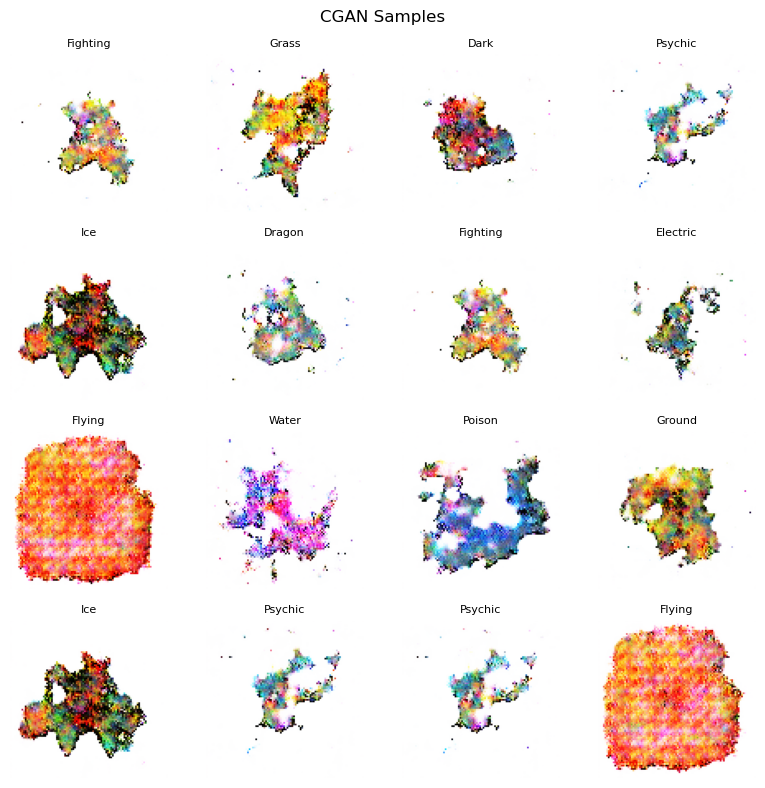

In [ ]:
cgan_history = fit_cgan(
    generator=cgan_generator,
    discriminator=cgan_discriminator,
    loader=train_loader,
    latent_dim=latent_dim,
    device=device,
    epochs=100,
)
# Plot loss curves

plot_loss_curves(dcgan_history, title="cGAN Training Loss")

show_generated_samples(
    cgan_generator.to(device),
    latent_dim=latent_dim,
    device=device,
    pokemon_types=POKEMON_TYPES,
    title="CGAN Samples",
)


In [ ]:
os.makedirs("models", exist_ok=True)
torch.save(generator.state_dict(), "models/generator.pth")
print("Generator weights saved to models/generator.pth")